In [9]:
import numpy as np
import networkx as nx
import pprint

from spidercss.cat_at_origin import *
from spidercss.utils import load_qecc
from spidercss.hook_errors import characterize_stabilizer_splits, explain_safe_splits
from spidercss.utils import get_conj_M
from resource_scheduling import plan_resource_aware_reuse
from qubit_reuse import build_circuit_dag
from qubit_reuse import dag_to_circuit


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
code = "7_1_3"
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)
t = d // 2
basis = "X" if code in ("8_3_2", "15_1_3", "49_1_5", "95_1_7") else "Z"
if basis == "X":
    H_x, H_z = H_z, H_x
    L_x, L_z = L_z, L_x
cost, row_M = row_optimize_matrix(H_x, t=t, max_basis_tries=1_000)  # |0>

for r in get_conj_M(row_M):
    print(f"\t[{r[0]}", end="")
    for e in r[1:]:
        print(f", {e}", end="")
    print("],")
print(cost)

	[1, 1, 0, 0, 1, 0, 0],
	[1, 0, 1, 0, 1, 0, 1],
	[1, 0, 0, 1, 0, 0, 1],
	[0, 0, 0, 0, 1, 1, 1],
17


In [11]:
explain_safe_splits(characterize_stabilizer_splits(get_conj_M(row_M)))

Stabilizer Support: (0, 2, 4, 6) (Weight 4)
  Prefix Size Safety Ratios:
    [2, 2]:     6 /     6 (Universally Safe)
--------------------------------------------------


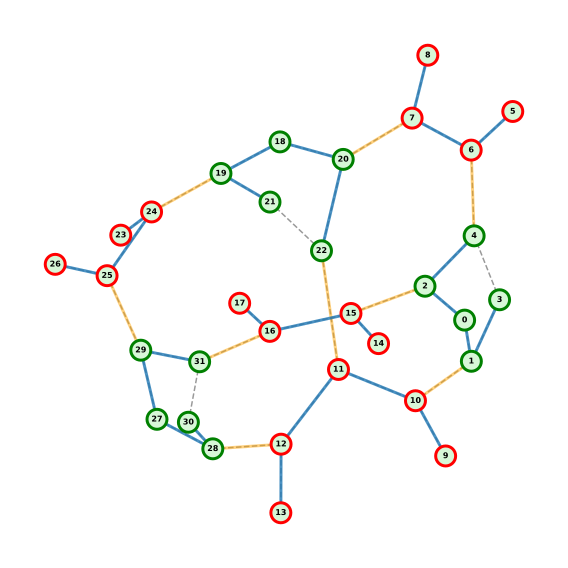

--- TikziT Forest ---
\begin{tikzpicture}
	\begin{pgfonlayer}{nodelayer}
		\node [style=Z] (0) at (-3.20, -1.62) {0};
		\node [style=Z] (1) at (-2.23, -2.83) {1};
		\node [style=Z] (2) at (-3.23, -0.13) {2};
		\node [style=Z_mark] (3) at (-2.44, -1.95) {3};
		\node [style=Z_flag] (4) at (-1.90, -0.83) {4};
		\node [style=X] (5) at (0.45, 0.04) {5};
		\node [style=X] (6) at (-0.06, -0.67) {6};
		\node [style=X] (7) at (1.60, -0.82) {7};
		\node [style=X_mark] (8) at (2.38, -0.41) {8};
		\node [style=X] (9) at (-0.84, -5.00) {9};
		\node [style=X] (10) at (-0.79, -3.76) {10};
		\node [style=X] (11) at (0.63, -2.86) {11};
		\node [style=X] (12) at (-0.45, -2.02) {12};
		\node [style=X_mark] (13) at (-1.01, -3.17) {13};
		\node [style=X] (14) at (-4.64, 2.33) {14};
		\node [style=X] (15) at (-3.71, 1.59) {15};
		\node [style=X] (16) at (-2.84, 2.79) {16};
		\node [style=X_mark] (17) at (-3.03, 3.97) {17};
		\node [style=Z] (18) at (4.00, -0.44) {18};
		\node [style=Z] (19) at (3.90, 0.55) 

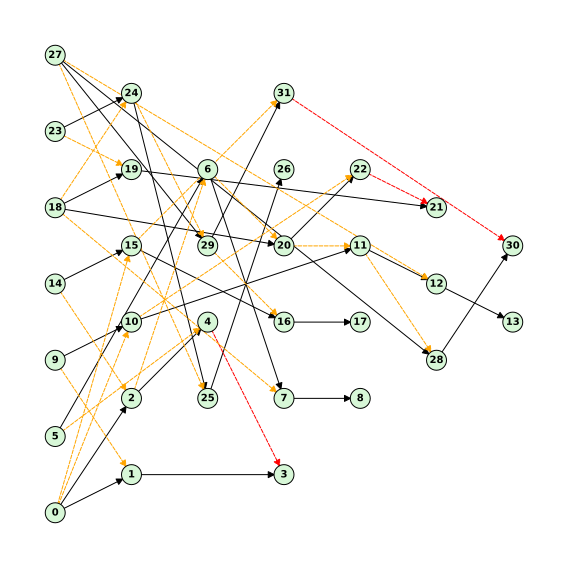

--- TikziT DiGraph ---
\begin{tikzpicture}
	\begin{pgfonlayer}{nodelayer}
		\node [style=plain] (0) at (-3.21, -4.10) {0};
		\node [style=plain] (1) at (-1.84, -3.42) {1};
		\node [style=plain] (2) at (-1.84, -2.05) {2};
		\node [style=plain] (3) at (0.90, -3.42) {3};
		\node [style=plain] (4) at (-0.47, -0.68) {4};
		\node [style=plain] (5) at (-3.21, -2.74) {5};
		\node [style=plain] (6) at (-0.47, 2.05) {6};
		\node [style=plain] (7) at (0.90, -2.05) {7};
		\node [style=plain] (8) at (2.26, -2.05) {8};
		\node [style=plain] (9) at (-3.21, -1.37) {9};
		\node [style=plain] (10) at (-1.84, -0.68) {10};
		\node [style=plain] (11) at (2.26, 0.68) {11};
		\node [style=plain] (12) at (3.63, 0.00) {12};
		\node [style=plain] (13) at (5.00, -0.68) {13};
		\node [style=plain] (14) at (-3.21, 0.00) {14};
		\node [style=plain] (15) at (-1.84, 0.68) {15};
		\node [style=plain] (16) at (0.90, -0.68) {16};
		\node [style=plain] (17) at (2.26, -0.68) {17};
		\node [style=plain] (18) at (-3.21, 1.3

In [12]:
circ = cat_at_origin(H_x, d, basis=basis, draw_solutions=True, analyze_hook_errors=True)
# circ2 = cat_at_origin(row_M, d, basis=basis, draw_solutions=False, analyze_hook_errors=False)

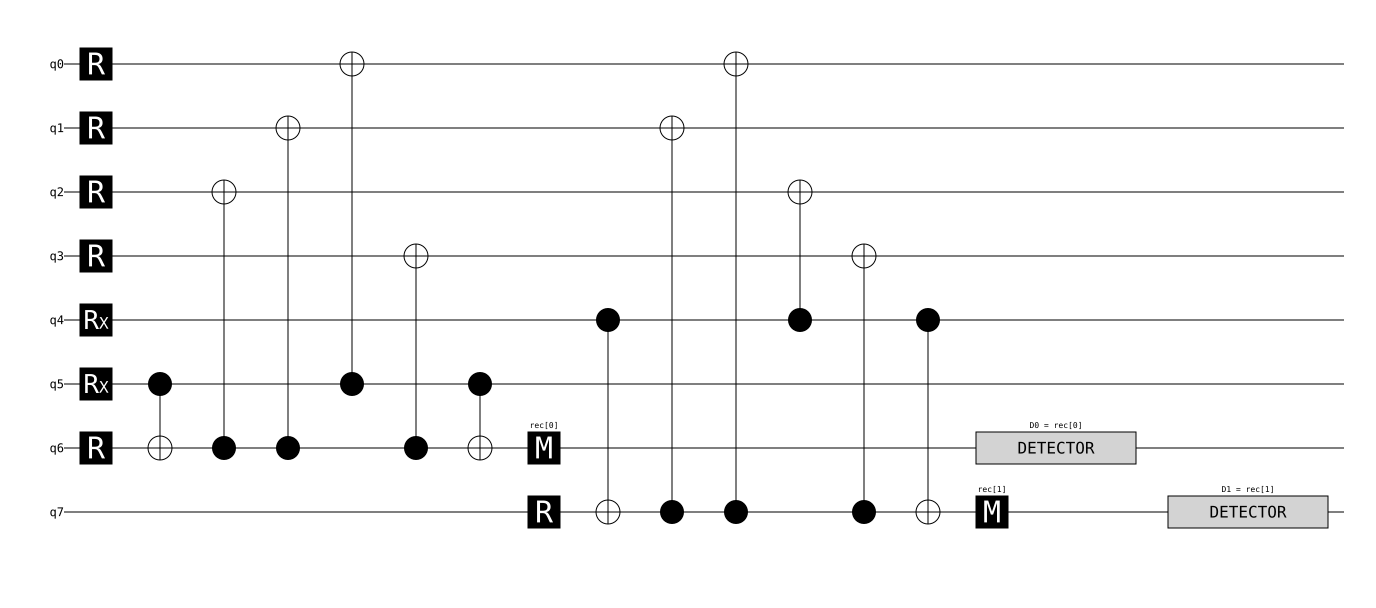

In [6]:
circ.diagram('timeline-svg')

In [36]:
circuit = circ.copy()
circuit.append("M" + basis, range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [37]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_z.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 15
Num Flags: 3
Num qubits: 10
Depth: 7


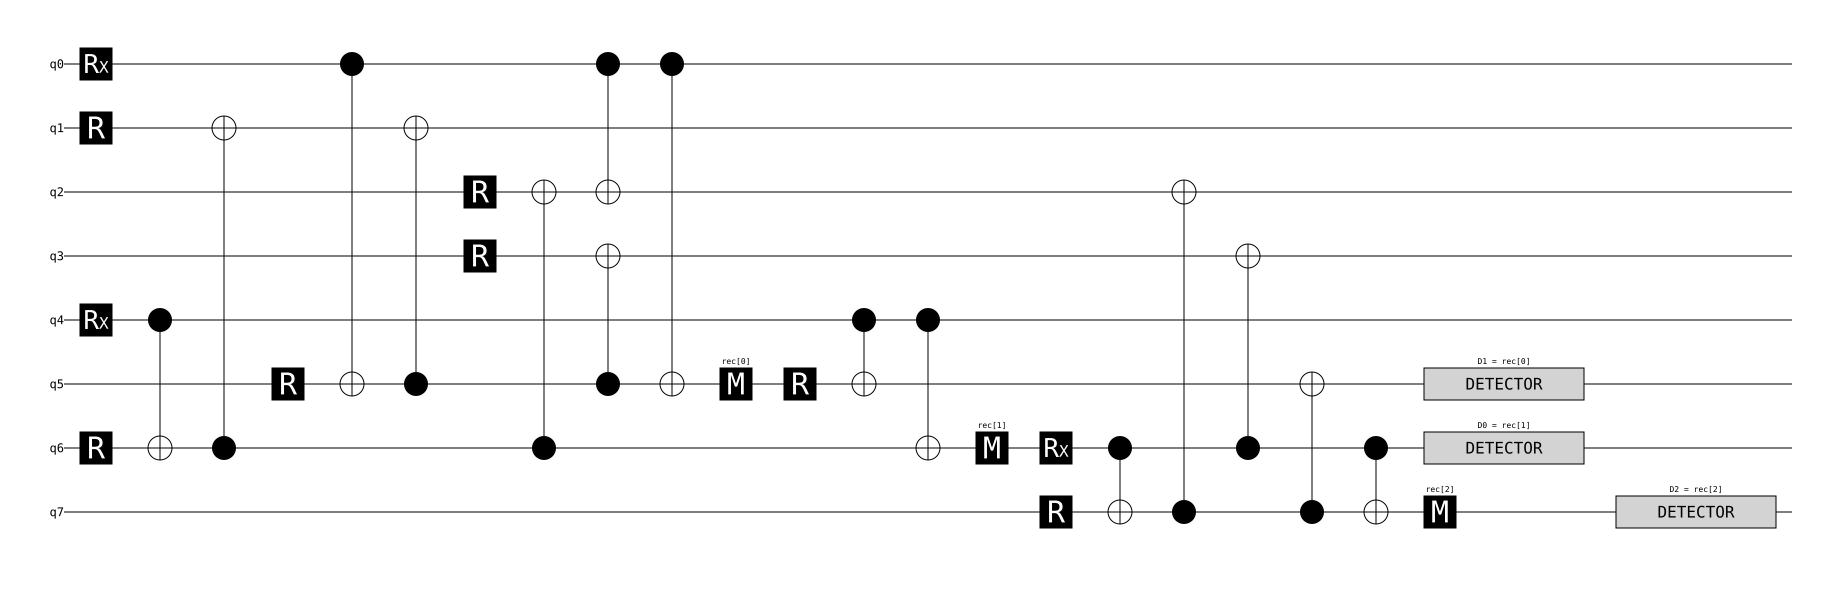

In [38]:
reuse_plan = plan_resource_aware_reuse(
    circ, H_x.shape[1], heuristic="decross_greedy", max_time_seconds=300.0,
    target=ReuseTarget.QUBITS,
)
circ_with_reuse = reuse_plan.circuit
circ_with_reuse.diagram('timeline-svg')

In [30]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ_with_reuse.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ_with_reuse.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 20
Num qubits: 12
Depth: 12


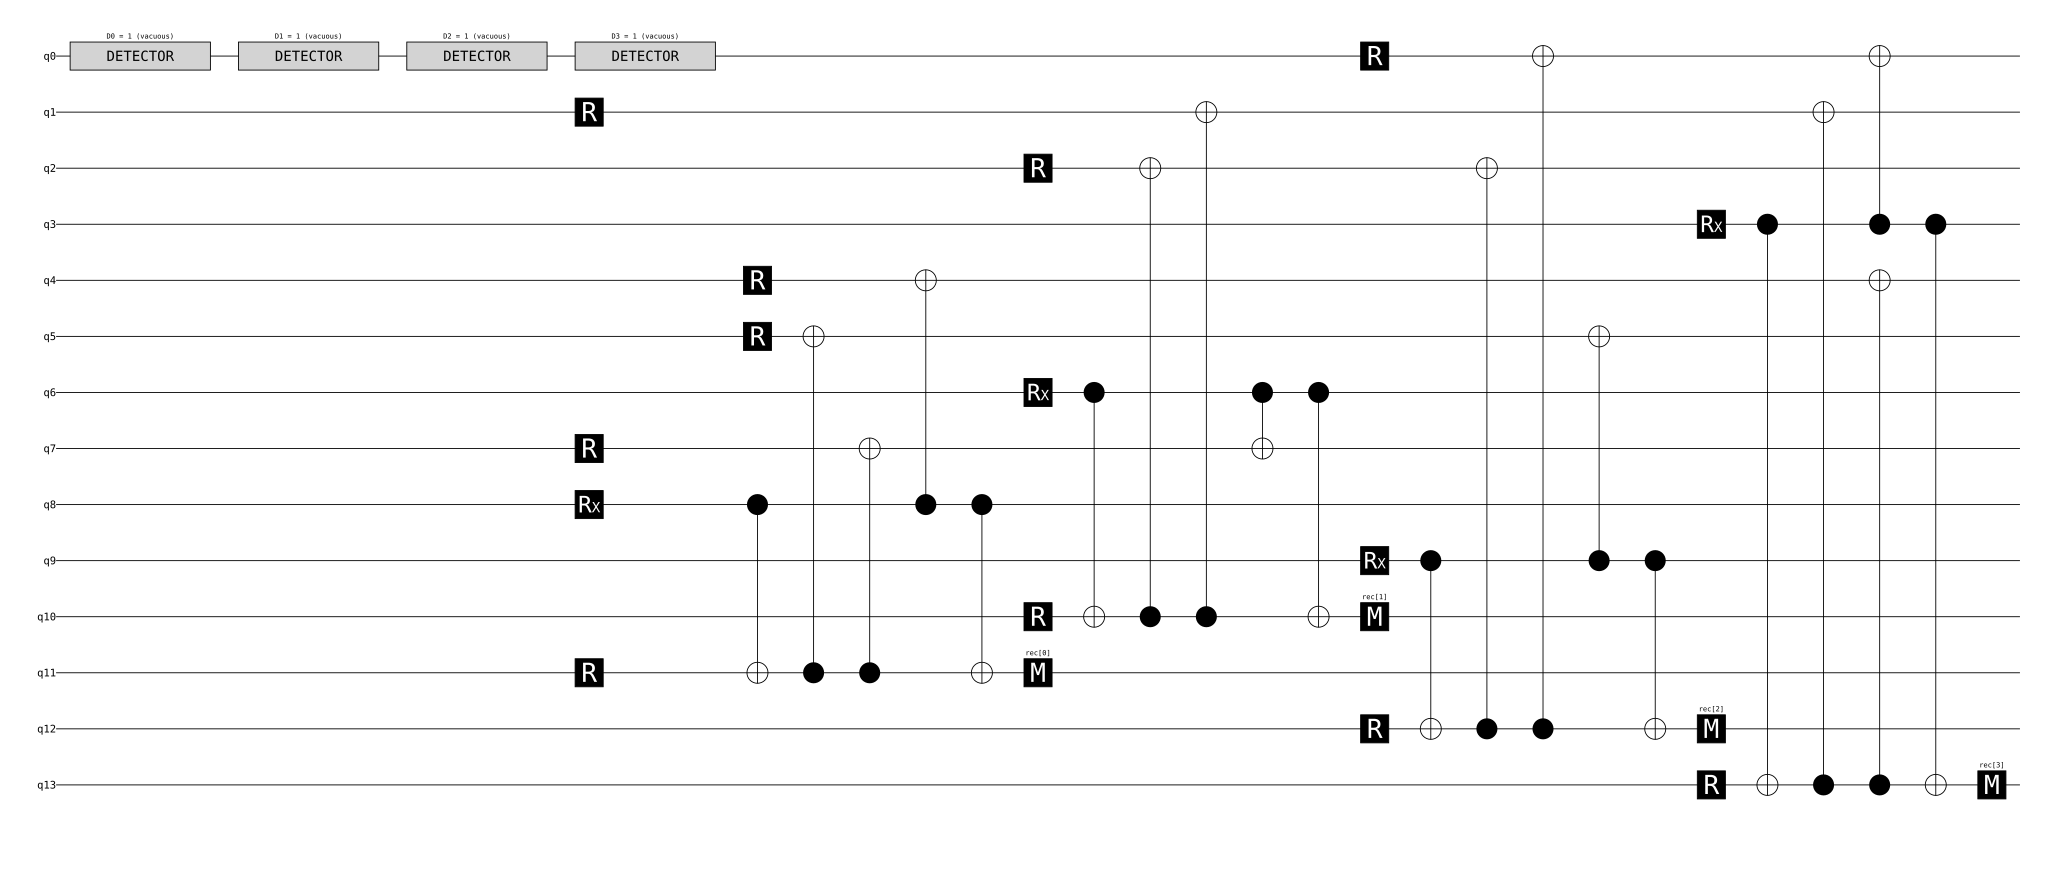

In [31]:
cao_dag = build_circuit_dag(circ)
cao_scheduled, _ = dag_to_circuit(cao_dag, heuristic="exact")
cao_scheduled.diagram('timeline-svg')

Num CX: 74
Num qubits: 23
Depth: 45


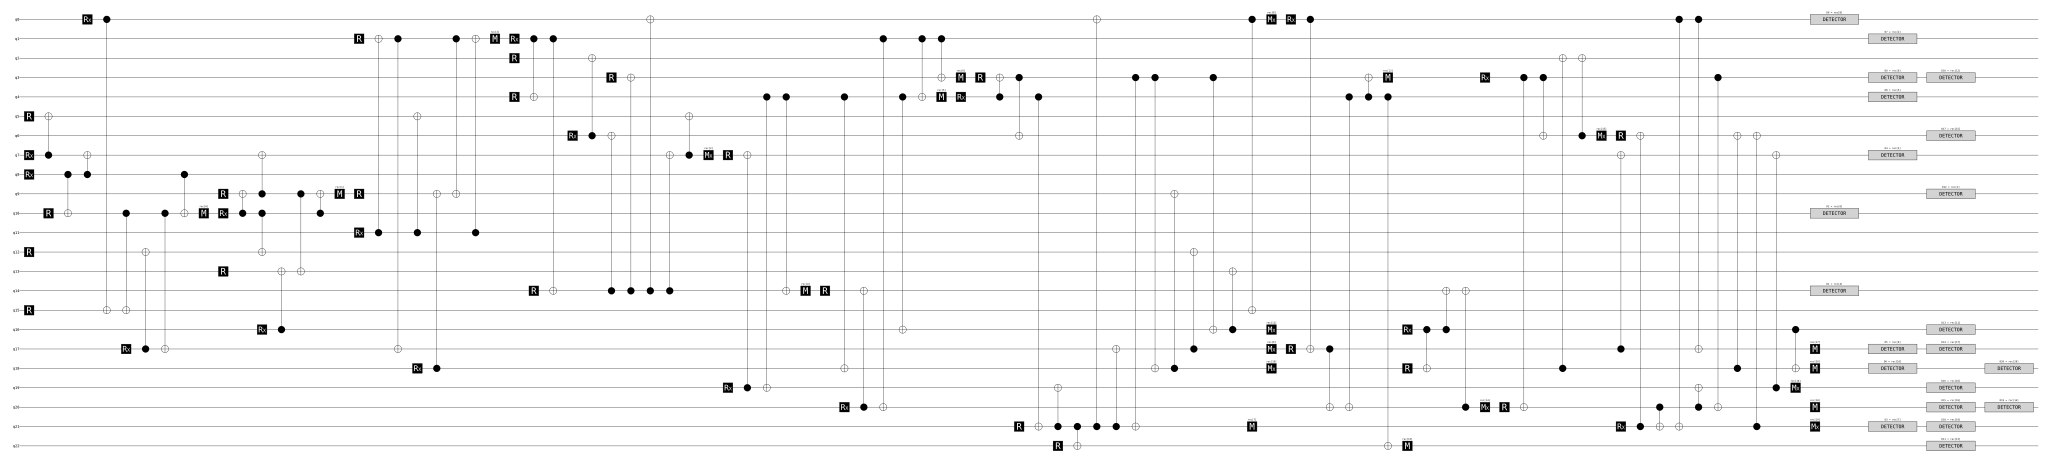

In [13]:
circ_reused = cat_at_origin(row_M, d, basis=basis, draw_solutions=False, analyze_hook_errors=True, reuse_target=ReuseTarget.QUBITS)

raw_cnots = [l for (name, l, _) in circ_reused.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ_reused.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

circ_reused.diagram('timeline-svg')